# 6. Инженерия промптов (Prompt Engineering)

---

## Содержание

1. Введение в инженерию промптов
2. Загрузка модели и базовая генерация текста
3. Параметры генерации: temperature, top_k, top_p
4. Визуализация влияния параметров
5. Основы составления промптов
6. Обучение в контексте (In-Context Learning)
7. Цепочечные промпты и декомпозиция задач
8. Цепочка рассуждений (Chain-of-Thought)
9. Верификация выходных данных модели
10. Самостоятельные задания

## 1. Введение в инженерию промптов

Инженерия промптов (Prompt Engineering) -- это искусство и наука составления
входных текстов (промптов) для языковых моделей таким образом, чтобы получить
от них наиболее полезные и точные ответы.

Ключевые идеи:

- Языковая модель предсказывает следующий токен на основе контекста.
- Качество ответа напрямую зависит от формулировки запроса.
- Существуют проверенные техники и паттерны для улучшения результатов.
- Параметры генерации (temperature, top_k, top_p) влияют на разнообразие и детерминированность выхода.

В этом блокноте мы будем использовать модель GPT-2 от OpenAI через библиотеку
HuggingFace Transformers. Эта модель легковесная и работает на CPU.

## 2. Загрузка модели и базовая генерация текста

Установим необходимые библиотеки и загрузим модель GPT-2.

In [ ]:
# Установка зависимостей (раскомментируйте при необходимости)
# !pip install transformers torch matplotlib numpy pandas -q

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Фиксируем случайное зерно для воспроизводимости
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Загрузка модели и токенизатора
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print("Модель GPT-2 загружена успешно.")
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Модель GPT-2 загружена успешно.
Количество параметров: 124,439,808


GPT-2 -- это авторегрессионная языковая модель с архитектурой Transformer-декодер.
Она генерирует текст последовательно, предсказывая один токен за другим на основе
предыдущего контекста.

In [ ]:
def generate_text(prompt, max_new_tokens=50, temperature=1.0, top_k=0, top_p=1.0,
                   do_sample=True, num_return_sequences=1):
    """Генерация текста с заданными параметрами."""
    input_ids = tokenizer.encode(prompt, return_tensors="pt")

    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k if top_k > 0 else None,
            top_p=top_p,
            do_sample=do_sample,
            num_return_sequences=num_return_sequences,
            pad_token_id=tokenizer.eos_token_id
        )

    results = []
    for i in range(num_return_sequences):
        text = tokenizer.decode(outputs[i], skip_special_tokens=True)
        results.append(text)

    return results if num_return_sequences > 1 else results[0]

# Пример базовой генерации
prompt = "Artificial intelligence is"
result = generate_text(prompt, max_new_tokens=40, temperature=0.7)
print(f"Промпт: {prompt}")
print(f"Результат: {result}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Промпт: Artificial intelligence is
Результат: Artificial intelligence is a hot topic in the field of AI research, but it is still hard to see how we can make an AI that is capable of solving problems for everyone. In this article, we'll go over


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            ## 3. Параметры генерации: temperature, top_k, top_p

Параметры генерации контролируют, как модель выбирает следующий токен:

**Temperature** (температура):
- Регулирует "остроту" распределения вероятностей.
- Низкая температура (0.1-0.3): модель уверенно выбирает наиболее вероятные токены, результат предсказуем.
- Высокая температура (1.0-2.0): распределение "сглаживается", модель чаще выбирает менее вероятные токены, результат разнообразнее.

**Top-k**:
- Ограничивает выбор k наиболее вероятными токенами.
- top_k=1: жадный поиск (всегда самый вероятный токен).
- top_k=50: модель выбирает из 50 лучших кандидатов.

**Top-p** (nucleus sampling):
- Выбирает минимальное множество токенов, сумма вероятностей которых превышает p.
- top_p=0.9: берем токены, покрывающие 90% вероятностной массы.
- Адаптивно сужает или расширяет множество кандидатов.

In [ ]:
# Демонстрация влияния temperature
prompt = "The future of technology is"

print("=== Влияние температуры на генерацию ===")
print(f"Промпт: {prompt}")
print()

for temp in [0.1, 0.5, 1.0, 1.5]:
    torch.manual_seed(SEED)
    result = generate_text(prompt, max_new_tokens=30, temperature=temp)
    print(f"Temperature={temp}:")
    print(f"  {result}")
    print()
    result = generate_text(prompt, max_new_tokens=30, temperature=temp)
    print(f"Temperature={temp}:")
    print(f"  {result}")
    print()


=== Влияние температуры на генерацию ===
Промпт: The future of technology is

Temperature=0.1:
  The future of technology is not yet clear. But it is clear that the future of the Internet is not yet clear.

The Internet is not yet clear.



Temperature=0.1:
  The future of technology is not yet clear. But it is clear that the future of the Internet is not yet clear.

The Internet is not yet clear. But it

Temperature=0.5:
  The future of technology is uncertain and the future of the workplace is uncertain," said Lee. "We want to make sure that we have a strong workplace culture where everyone has the

Temperature=0.5:
  The future of technology is an exciting one.

Image copyright Thinkstock Image caption The world's most intelligent cars are expected to be unveiled at the Geneva Motor Show in 2018

Temperature=1.0:
  The future of technology is uncertain and could poison the U.S. economy," Lee said. "We should listen to people. The U.S. Government makes mistakes –

Temperature=1.0:
  

## 4. Визуализация влияния параметров

Рассмотрим, как temperature изменяет распределение вероятностей следующего токена.

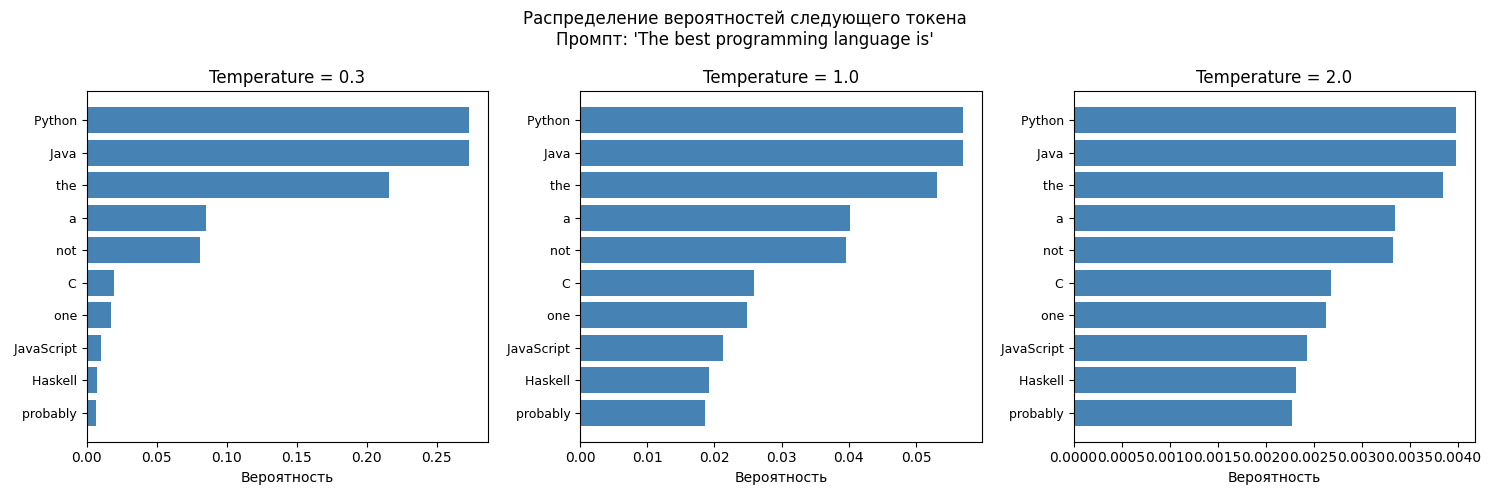

In [ ]:
def get_next_token_probs(prompt, temperature=1.0, top_k=20):
    """Получить вероятности следующих токенов."""
    input_ids = tokenizer.encode(prompt, return_tensors="pt")

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits[0, -1, :]

    # Применяем температуру
    scaled_logits = logits / temperature
    probs = torch.softmax(scaled_logits, dim=-1)

    # Берем top_k токенов
    top_probs, top_indices = torch.topk(probs, top_k)
    tokens = [tokenizer.decode([idx]) for idx in top_indices]

    return tokens, top_probs.numpy()

prompt = "The best programming language is"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
temperatures = [0.3, 1.0, 2.0]

for ax, temp in zip(axes, temperatures):
    tokens, probs = get_next_token_probs(prompt, temperature=temp, top_k=10)
    bars = ax.barh(range(len(tokens)), probs, color="steelblue")
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel("Вероятность")
    ax.set_title(f"Temperature = {temp}")
    ax.invert_yaxis()

fig.suptitle(f"Распределение вероятностей следующего токена\nПромпт: '{prompt}'",
             fontsize=12)
plt.tight_layout()
plt.show()

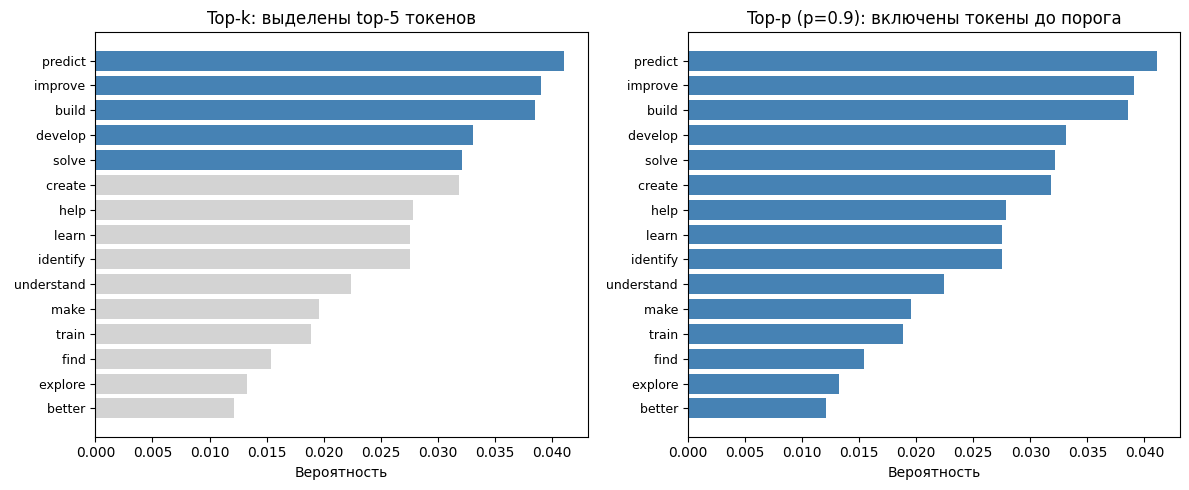

In [ ]:
# Визуализация top_k и top_p
prompt = "Machine learning can be used to"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Top-k визуализация
tokens, probs = get_next_token_probs(prompt, temperature=1.0, top_k=15)
colors = ["steelblue" if i < 5 else "lightgray" for i in range(len(tokens))]
axes[0].barh(range(len(tokens)), probs, color=colors)
axes[0].set_yticks(range(len(tokens)))
axes[0].set_yticklabels(tokens, fontsize=9)
axes[0].set_xlabel("Вероятность")
axes[0].set_title("Top-k: выделены top-5 токенов")
axes[0].invert_yaxis()

# Top-p визуализация
cumprobs = np.cumsum(probs)
threshold_p = 0.9
colors_p = ["steelblue" if cumprobs[i] <= threshold_p or i == 0 else "lightgray"
            for i in range(len(tokens))]
# Первый токен за порогом тоже включаем
for i in range(len(cumprobs)):
    if cumprobs[i] > threshold_p:
        colors_p[i] = "orange"
        break

axes[1].barh(range(len(tokens)), probs, color=colors_p)
axes[1].set_yticks(range(len(tokens)))
axes[1].set_yticklabels(tokens, fontsize=9)
axes[1].set_xlabel("Вероятность")
axes[1].set_title(f"Top-p (p={threshold_p}): включены токены до порога")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Основы составления промптов

Качество промпта определяет качество ответа модели. Основные принципы:

1. **Четкость и конкретность**: формулируйте запрос максимально точно.
2. **Контекст**: предоставляйте модели необходимую информацию.
3. **Формат вывода**: указывайте, в каком формате нужен ответ.
4. **Роль**: задавайте роль для модели ("Ты -- опытный программист...").
5. **Ограничения**: указывайте, чего делать не нужно.

In [ ]:
# Пример: простой промпт vs. детализированный промпт

# Простой промпт
simple_prompt = "Write a summary of Python."
result_simple = generate_text(simple_prompt, max_new_tokens=60, temperature=0.7)
print("=== Простой промпт ===")
print(f"Промпт: {simple_prompt}")
print(f"Результат: {result_simple}")
print()

# Детализированный промпт
detailed_prompt = (
    "Write a concise 2-sentence summary of the Python programming language, "
    "focusing on its main use cases and key advantages."
)
result_detailed = generate_text(detailed_prompt, max_new_tokens=60, temperature=0.7)
print("=== Детализированный промпт ===")
print(f"Промпт: {detailed_prompt}")
print(f"Результат: {result_detailed}")

=== Простой промпт ===
Промпт: Write a summary of Python.
Результат: Write a summary of Python. In Python, you can use a list of strings to represent a list of objects. The literal list is just one list of objects.

>>> def list(self): print "The following list is a list of objects." Console.WriteLine(self.items()) >>> list(1,

=== Детализированный промпт ===
Промпт: Write a concise 2-sentence summary of the Python programming language, focusing on its main use cases and key advantages.
Результат: Write a concise 2-sentence summary of the Python programming language, focusing on its main use cases and key advantages. For the Python community, this is an excellent introduction to the basics of Python's programming language, and also a good introduction to commonly used features.

The Python programming language is a powerful and flexible language that can be used to build applications or programs, as well as for almost any other work.


In [ ]:
# Пример: указание формата вывода
format_prompt = """List the top 3 benefits of exercise:
1."""

result = generate_text(format_prompt, max_new_tokens=60, temperature=0.5)
print("=== Промпт с заданным форматом ===")
print(result)

=== Промпт с заданным форматом ===
List the top 3 benefits of exercise:
1. Speed.
2. Strength.
3. Fitness.
4. Health.
5. Happiness.
6. Sleep.
7. Sleep deprivation.
8. Stress.
9. Feelings.
10. Heart rate.
11. Sleep.
12. Sleep deprivation


## 6. Обучение в контексте (In-Context Learning)

Одна из ключевых возможностей языковых моделей -- способность учиться на примерах,
предоставленных прямо в промпте, без обновления весов модели.

Типы обучения в контексте:

- **Zero-shot**: задача без примеров, только инструкция.
- **One-shot**: один пример перед запросом.
- **Few-shot**: несколько примеров (обычно 2-5) перед запросом.

Чем больше примеров, тем лучше модель понимает паттерн ожидаемого ответа.

In [ ]:
# Zero-shot: классификация тональности без примеров
zero_shot_prompt = """Classify the sentiment of the following text as positive or negative.

Text: "This movie was absolutely wonderful and heartwarming."
Sentiment:"""

result = generate_text(zero_shot_prompt, max_new_tokens=5, temperature=0.1)
print("=== Zero-shot классификация ===")
print(result)

=== Zero-shot классификация ===
Classify the sentiment of the following text as positive or negative.

Text: "This movie was absolutely wonderful and heartwarming."
Sentiment: "I'm so happy


In [ ]:
# One-shot: один пример перед запросом
one_shot_prompt = """Classify the sentiment of the text as positive or negative.

Text: "The food was terrible and the service was slow."
Sentiment: negative

Text: "I had an amazing experience at this hotel."
Sentiment:"""

result = generate_text(one_shot_prompt, max_new_tokens=5, temperature=0.1)
print("=== One-shot классификация ===")
print(result)

=== One-shot классификация ===
Classify the sentiment of the text as positive or negative.

Text: "The food was terrible and the service was slow."
Sentiment: negative

Text: "I had an amazing experience at this hotel."
Sentiment: positive

Text:


In [ ]:
# Few-shot: несколько примеров
few_shot_prompt = """Classify the sentiment of the text as positive or negative.

Text: "The food was terrible and the service was slow."
Sentiment: negative

Text: "What a beautiful day for a walk in the park!"
Sentiment: positive

Text: "The product broke after just one week of use."
Sentiment: negative

Text: "This book changed my perspective on life."
Sentiment:"""

result = generate_text(few_shot_prompt, max_new_tokens=5, temperature=0.1)
print("=== Few-shot классификация ===")
print(result)

=== Few-shot классификация ===
Classify the sentiment of the text as positive or negative.

Text: "The food was terrible and the service was slow."
Sentiment: negative

Text: "What a beautiful day for a walk in the park!"
Sentiment: positive

Text: "The product broke after just one week of use."
Sentiment: negative

Text: "This book changed my perspective on life."
Sentiment: positive

Text:


Обратите внимание: с увеличением количества примеров модель лучше понимает
формат ответа и шаблон задачи. Это особенно полезно для моделей малого размера,
таких как GPT-2, которые имеют ограниченные возможности zero-shot.

## 7. Цепочечные промпты и декомпозиция задач

Сложные задачи лучше разбивать на последовательные шаги. Вместо одного
большого промпта, мы используем цепочку промптов, где выход одного шага
становится входом для следующего.

Преимущества:
- Каждый шаг проще и контролируемее.
- Легче отлаживать и корректировать.
- Можно добавлять верификацию между шагами.

In [ ]:
# Цепочечный промпт: многоступенчатая обработка
# Шаг 1: извлечение ключевых слов
step1_prompt = """Extract the main keywords from the following text.

Text: "Machine learning algorithms can analyze large datasets to find patterns
and make predictions. Deep learning, a subset of machine learning, uses neural
networks with many layers."

Keywords:"""

step1_result = generate_text(step1_prompt, max_new_tokens=20, temperature=0.3)
print("Шаг 1 -- Извлечение ключевых слов:")
print(step1_result)
print()

# Шаг 2: используем результат для генерации краткого описания
step2_prompt = f"""Using the following keywords, write a one-sentence definition.

Keywords: machine learning, deep learning, neural networks, patterns, predictions

Definition:"""

step2_result = generate_text(step2_prompt, max_new_tokens=40, temperature=0.5)
print("Шаг 2 -- Генерация определения на основе ключевых слов:")
print(step2_result)

Шаг 1 -- Извлечение ключевых слов:
Extract the main keywords from the following text.

Text: "Machine learning algorithms can analyze large datasets to find patterns
and make predictions. Deep learning, a subset of machine learning, uses neural
networks with many layers."

Keywords: Machine learning algorithms can analyze large datasets to find patterns and make predictions. Deep learning, a subset of

Шаг 2 -- Генерация определения на основе ключевых слов:
Using the following keywords, write a one-sentence definition.

Keywords: machine learning, deep learning, neural networks, patterns, predictions

Definition: A machine learning algorithm uses the following keywords to define a particular type of machine learning algorithm:

Machine Learning

Machine Learning is a type of machine learning algorithm that is used to classify and predict


## 8. Цепочка рассуждений (Chain-of-Thought)

Chain-of-Thought (CoT) -- техника, при которой модель явно проходит
через промежуточные шаги рассуждений перед финальным ответом.

Это особенно полезно для задач, требующих логики или арифметики.
Даже простое добавление фразы "Let's think step by step" может
улучшить качество ответа.

Варианты CoT:
- **Zero-shot CoT**: добавление "Let's think step by step"
- **Few-shot CoT**: примеры с пошаговым рассуждением
- **Tree-of-Thought**: рассмотрение нескольких путей рассуждения

In [ ]:
# Zero-shot CoT пример
# Без CoT
no_cot = """Q: If a store has 15 apples and sells 7, then receives 12 more, how many apples are there?
A:"""
result_no_cot = generate_text(no_cot, max_new_tokens=20, temperature=0.1)
print("=== Без CoT ===")
print(result_no_cot)
print()

# С CoT
with_cot = """Q: If a store has 15 apples and sells 7, then receives 12 more, how many apples are there?
A: Let's think step by step."""
result_cot = generate_text(with_cot, max_new_tokens=50, temperature=0.3)
print("=== С Chain-of-Thought ===")
print(result_cot)

=== Без CoT ===
Q: If a store has 15 apples and sells 7, then receives 12 more, how many apples are there?
A: The store will have 15 apples.
Q: If a store has 15 apples and sells 7,

=== С Chain-of-Thought ===
Q: If a store has 15 apples and sells 7, then receives 12 more, how many apples are there?
A: Let's think step by step. I've been doing this for a while now, and I've never seen anything like this. I've seen a lot of people who are trying to sell their apples, but they're not getting any apples. They're not getting any apples. They


In [ ]:
# Few-shot CoT: примеры с рассуждениями
few_shot_cot = """Q: A shop had 20 items. They sold 8 on Monday and 5 on Tuesday. How many are left?
A: Let's solve step by step. Started with 20. Sold 8 on Monday: 20 - 8 = 12. Sold 5 on Tuesday: 12 - 5 = 7. Answer: 7.

Q: A farmer has 30 chickens. He buys 15 more and gives away 10. How many does he have?
A: Let's solve step by step. Started with 30. Bought 15: 30 + 15 = 45. Gave away 10: 45 - 10 = 35. Answer: 35.

Q: A library has 100 books. They lend out 25 and receive 40 new books. How many books are there now?
A: Let's solve step by step."""

result = generate_text(few_shot_cot, max_new_tokens=40, temperature=0.3)
print("=== Few-shot CoT ===")
print(result)

=== Few-shot CoT ===
Q: A shop had 20 items. They sold 8 on Monday and 5 on Tuesday. How many are left?
A: Let's solve step by step. Started with 20. Sold 8 on Monday: 20 - 8 = 12. Sold 5 on Tuesday: 12 - 5 = 7. Answer: 7.

Q: A farmer has 30 chickens. He buys 15 more and gives away 10. How many does he have?
A: Let's solve step by step. Started with 30. Bought 15: 30 + 15 = 45. Gave away 10: 45 - 10 = 35. Answer: 35.

Q: A library has 100 books. They lend out 25 and receive 40 new books. How many books are there now?
A: Let's solve step by step. Started with 100. Bought 100: 100 + 100 = 25. Answer: 25.

Q: A shop has 50 books. They sell 50 more and receive 50 new books. How many books


## 9. Верификация выходных данных модели

Языковые модели могут генерировать неточные или "галлюцинированные" ответы.
Важно проверять и фильтровать выходные данные.

Стратегии верификации:
- Сравнение нескольких генераций (самосогласованность).
- Проверка формата ответа (регулярные выражения, парсинг).
- Вычисление уверенности модели через вероятности токенов.

In [ ]:
# Самосогласованность (self-consistency):
# генерируем несколько ответов и смотрим, совпадают ли они

prompt = """Q: What is 23 + 47?
A: The answer is"""

print("=== Проверка самосогласованности ===")
answers = []
for i in range(5):
    torch.manual_seed(SEED + i)
    result = generate_text(prompt, max_new_tokens=5, temperature=0.8)
    # Извлекаем ответ после "The answer is"
    answer_part = result.split("The answer is")[-1].strip()
    answers.append(answer_part)
    print(f"Генерация {i+1}: {answer_part}")

print()
print(f"Все ответы: {answers}")
print(f"Модальный ответ (самый частый): требуется анализ уникальных значений")

=== Проверка самосогласованности ===
Генерация 1: : 29 + 9,
Генерация 2: that 23 + 47 is
Генерация 3: 23 + 47. 23
Генерация 4: that you are 2 +
Генерация 5: one of three. It

Все ответы: [': 29 + 9,', 'that 23 + 47 is', '23 + 47. 23', 'that you are 2 +', 'one of three. It']
Модальный ответ (самый частый): требуется анализ уникальных значений


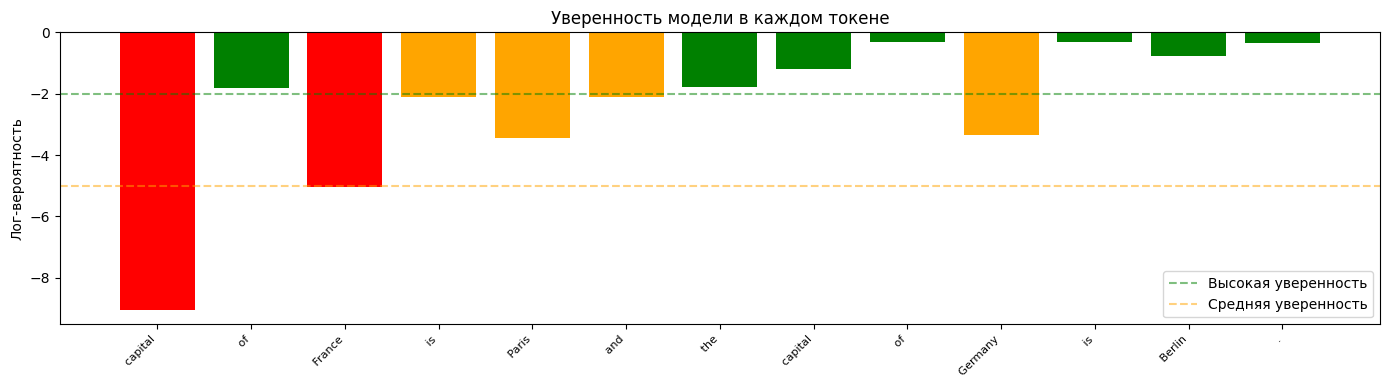

In [ ]:
# Визуализация вероятностей токенов для оценки уверенности модели
def get_token_log_probs(text):
    """Получить лог-вероятности для каждого токена в тексте."""
    input_ids = tokenizer.encode(text, return_tensors="pt")

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits

    # Вероятности для каждого следующего токена
    log_probs = torch.log_softmax(logits, dim=-1)

    token_log_probs = []
    tokens_text = []
    for i in range(1, input_ids.shape[1]):
        token_id = input_ids[0, i]
        lp = log_probs[0, i - 1, token_id].item()
        token_log_probs.append(lp)
        tokens_text.append(tokenizer.decode([token_id]))

    return tokens_text, token_log_probs

text = "The capital of France is Paris and the capital of Germany is Berlin."
tokens, log_probs = get_token_log_probs(text)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["green" if lp > -2 else "orange" if lp > -5 else "red" for lp in log_probs]
ax.bar(range(len(tokens)), log_probs, color=colors)
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Лог-вероятность")
ax.set_title("Уверенность модели в каждом токене")
ax.axhline(y=-2, color="green", linestyle="--", alpha=0.5, label="Высокая уверенность")
ax.axhline(y=-5, color="orange", linestyle="--", alpha=0.5, label="Средняя уверенность")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Самостоятельные задания

---

### Задание 1. Исследование параметров генерации

Напишите код, который:
1. Задает промпт по вашему выбору.
2. Генерирует текст при 5 разных значениях temperature: 0.1, 0.3, 0.7, 1.0, 1.5.
3. Для каждого значения генерирует 3 варианта (num_return_sequences=3).
4. Строит график, показывающий среднюю длину (в токенах) и разброс (стандартное отклонение) результатов в зависимости от temperature.

Подсказка: используйте функцию generate_text с параметром num_return_sequences.

In [ ]:
# Задание 1 -- ваш код здесь


### Задание 2. Классификация с помощью few-shot промптов

Создайте few-shot промпт для классификации текстов по тематике
(спорт, технологии, наука, политика). Требования:
1. Подготовьте по 2 примера для каждой из 4 категорий.
2. Протестируйте классификацию на 3 новых текстах.
3. Сравните результаты zero-shot и few-shot подходов для тех же текстов.

In [ ]:
# Задание 2 -- ваш код здесь


### Задание 3. Верификация через самосогласованность

Реализуйте функцию self_consistency_check, которая:
1. Принимает промпт и количество генераций N.
2. Генерирует N ответов с temperature=0.7.
3. Подсчитывает частоту каждого уникального ответа.
4. Возвращает наиболее частый ответ и его долю (уверенность).
5. Визуализирует распределение ответов в виде столбчатой диаграммы.

Протестируйте функцию на 3 разных арифметических задачах.

In [ ]:
# Задание 3 -- ваш код здесь


---

6. Инженерия промптов.